## Import

In [1]:
import numpy as np
import scipy
from scipy import signal
from scipy.signal import hilbert
from scipy import integrate

from pathlib import Path

try:
    from scipy.integrate import simps
except ImportError:
    from scipy.integrate import simpson

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

import warnings
import re
import matplotlib.image as mpimg
import os
import shutil
import csv
import glob

from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")


# VERY CAREFULLY not to delete other folders!
if os.path.isdir("ims"):
    shutil.rmtree("ims")
    print("The ims folder is deleted and created again")
    print(" ")

os.makedirs("ims", exist_ok=True)

os.makedirs("ims/png", exist_ok=True)
os.makedirs("ims/pdf", exist_ok=True)


volume = 160.1 # для Si в A^3

# m0_cut_1 = 10500  # 21 fs: for exp fit
# m0_cut_2 = 6250   # 12.5 fs: for full drude fit (needs to be adjusted in accordance to z_pump energy)
# # 3749 (7.5 fms), 5999 (12 fms)

# m0_cut_3 = 5250 # 10.5 fs: start of integration for Δk analysis. half of probe pulse duration

# In[116]:


plt.rcParams['font.family'] = 'serif'
import matplotlib
# matplotlib.use('Agg') for server (not necessary)
# matplotlib.use("TkAgg")
# print(matplotlib.get_backend())


## extract

In [2]:
def extract_c_num(s):
    start = s.index('c') + 1
    end = s.index('_', start)
    return int(s[start:end])

def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_k_num(s):
    start = s.index('_k') + 2
    end = s.index('_', start)
    return int(s[start:end])

# def extract_a_num(s):
#     start = s.index('_a') + 2
#     end = s.index('_', start)
#     return float(s[start:end])

def extract_r_num(s):
    start = s.index('_r') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_i_num(s):
    start = s.index('_i') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    if match:
        return float(match.group(1).replace("d", "e"))

def extract_amorphous_value(name):
    tokens = name.split("_")
    for i, token in enumerate(tokens):
        if token == "amorphous" and i + 1 < len(tokens):
            return float(tokens[i + 1])

In [3]:
def blue_red_gradient(n):
    """
    Возвращает список из n цветов (hex),
    создающих линейный градиент от синего к красному.
    """
    colors = []
    
    for i in range(n):
        t = i / (n - 1)  # параметр от 0 до 1
        
        r = t            # красный растёт
        g = 0            # зелёный фиксирован
        b = 1 - t        # синий убывает
        
        colors.append(to_hex((r, g, b)))
    
    return colors

## sorted folders

In [4]:
# ax = 'z'

# folders = [name for name in os.listdir('.') if os.path.isdir(os.path.join('.', name))]

# # folders = [f for f in folders if f.startswith('c')]
# folders = [f for f in folders 
#            if f.startswith('c') 
#            and os.path.isfile(os.path.join(f, 'lr_response.data'))]
#            # and not os.path.isdir(os.path.join(f, 'restart'))]


# # print(folders)


# if "amorphous" in folders[0]:
#     sorted_folders = sorted(folders, key=extract_amorphous_value, reverse=True)

# else:
#     sorted_folders = sorted(folders, key=lambda s: (extract_p(s), extract_c_num(s), extract_r_num(s), extract_s_num(s), extract_k_num(s), extract_i_num(s)))

# print("Sorted folders are:")
# for f in sorted_folders:
#     print(f)
# print(" ")

## lr analysis

In [5]:
init_folders = ['lr_data_111', 'lr_data_sigma', 'lr_data_amorphous']

In [6]:
lr_response_columns=[
            'Energy_eV',
            'Re_sigma_x', 'Re_sigma_y','Re_sigma_z',
            'Im_sigma_x', 'Im_sigma_y','Im_sigma_z',
            'Re_eps_x',   'Re_eps_y',  'Re_eps_z',
            'Im_eps_x',   'Im_eps_y',  'Im_eps_z'
        ]

In [7]:
lr_rt_columns=['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

In [8]:
files_path = Path(init_folders[0]) / "data"
filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
lr_response_111_path = files_path/filenames_arr[0]
lr_rt_111_path = files_path/filenames_arr[1]

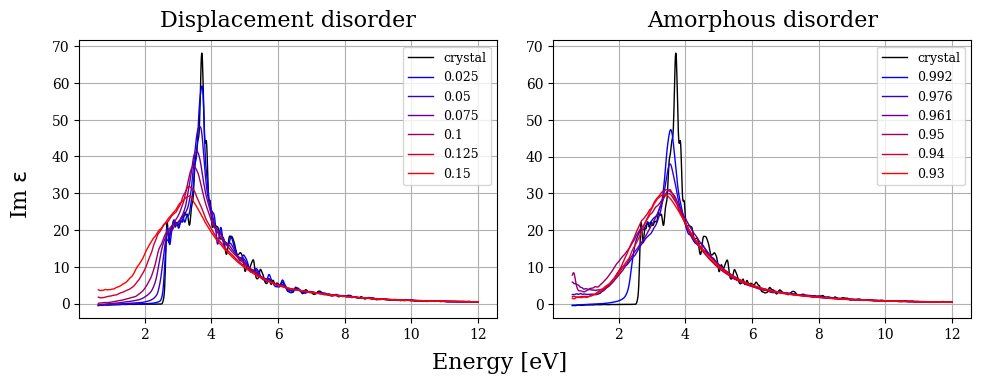

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# --- сколько графиков будет (по числу init_folders[1:]) ---
folders_to_plot = init_folders[1:]
nplots = len(folders_to_plot)

fig, axes = plt.subplots(1, nplots, figsize=(5*nplots, 4))

fig.subplots_adjust(wspace=0.9, hspace=1)

# если nplots == 1, axes не массив — поправим
if nplots == 1:
    axes = [axes]

for i, init_folder in enumerate(folders_to_plot):

    ax = axes[i]                 # <-- ВОТ ключевое: рисуем в ax, а не в plt
    # ax.set_ylim(0, 5)
    ax.grid(True)

    files_path = Path(init_folder) / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'lr_response' in f]

    colors = blue_red_gradient(6)

    # reference crystal
    df_ref = pd.read_csv(lr_response_111_path, comment='#', delim_whitespace=True, header=None)
    df_ref.columns = lr_response_columns
    ax.plot(df_ref['Energy_eV'][60:], df_ref['Im_eps_z'][60:],
            color='black', label='crystal', linewidth=1)

    # остальные кривые
    for j, f in enumerate(filenames_arr[:6]):
        df = pd.read_csv(files_path / f, comment='#', delim_whitespace=True, header=None)
        df.columns = lr_response_columns

        if 'amorphous' in f:
            labelname = extract_amorphous_value(f)
        else:
            labelname = extract_s_num(f[:20])

        ax.plot(df['Energy_eV'][60:], df['Im_eps_z'][60:],
                color=colors[j], label=labelname, linewidth=1)

    if i==0:
        ax.set_title('Displacement disorder', fontsize=16, y=1.02)

    if i==1:
        ax.set_title('Amorphous disorder', fontsize=16, y=1.02)

    # легенду можно на каждом, или только на последнем/первом
    ax.legend(fontsize=9)

# общие подписи (как в твоём примере)
fig.supxlabel("Energy [eV]", y=0.05, fontsize=16)
fig.supylabel(r"Im $\mathrm{\epsilon}$", x=0.01, fontsize=16)

plt.tight_layout()

plt.savefig("ims/png/im_epsilon.png", dpi=200, bbox_inches="tight")
plt.savefig("ims/pdf/im_epsilon.pdf", bbox_inches="tight")

plt.show()
plt.close(fig)

In [10]:
# 0.6, 1, 1.48, 2.13, 2.52

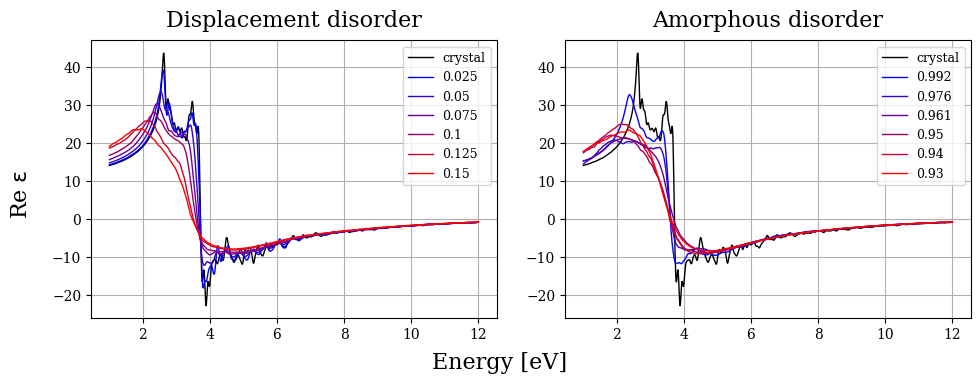

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# --- сколько графиков будет (по числу init_folders[1:]) ---
folders_to_plot = init_folders[1:]
nplots = len(folders_to_plot)

fig, axes = plt.subplots(1, nplots, figsize=(5*nplots, 4))

fig.subplots_adjust(wspace=0.9, hspace=1)

# если nplots == 1, axes не массив — поправим
if nplots == 1:
    axes = [axes]

for i, init_folder in enumerate(folders_to_plot):

    ax = axes[i]                 # <-- ВОТ ключевое: рисуем в ax, а не в plt
    # ax.set_ylim(0, 5)
    ax.grid(True)

    files_path = Path(init_folder) / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'lr_response' in f]

    colors = blue_red_gradient(6)

    # reference crystal
    df_ref = pd.read_csv(lr_response_111_path, comment='#', delim_whitespace=True, header=None)
    df_ref.columns = lr_response_columns
    ax.plot(df_ref['Energy_eV'][100:], df_ref['Re_eps_z'][100:],
            color='black', label='crystal', linewidth=1)

    # остальные кривые
    for j, f in enumerate(filenames_arr[:6]):
        df = pd.read_csv(files_path / f, comment='#', delim_whitespace=True, header=None)
        df.columns = lr_response_columns

        if 'amorphous' in f:
            labelname = extract_amorphous_value(f)
        else:
            labelname = extract_s_num(f[:20])

        ax.plot(df['Energy_eV'][100:], df['Re_eps_z'][100:],
                color=colors[j], label=labelname, linewidth=1)

    if i==0:
        ax.set_title('Displacement disorder', fontsize=16, y=1.02)

    if i==1:
        ax.set_title('Amorphous disorder', fontsize=16, y=1.02)

    # легенду можно на каждом, или только на последнем/первом
    ax.legend(fontsize=9)

# общие подписи (как в твоём примере)
fig.supxlabel("Energy [eV]", y=0.05, fontsize=16)
fig.supylabel(r"Re $\mathrm{\epsilon}$", x=0.01, fontsize=16)

plt.tight_layout()

plt.savefig("ims/png/re_epsilon.png", dpi=200, bbox_inches="tight")
plt.savefig("ims/pdf/re_epsilon.pdf", bbox_inches="tight")

plt.show()
plt.close(fig)

In [12]:
def get_phase(re_eps, im_eps):
    return np.angle(re_eps + 1j * im_eps)

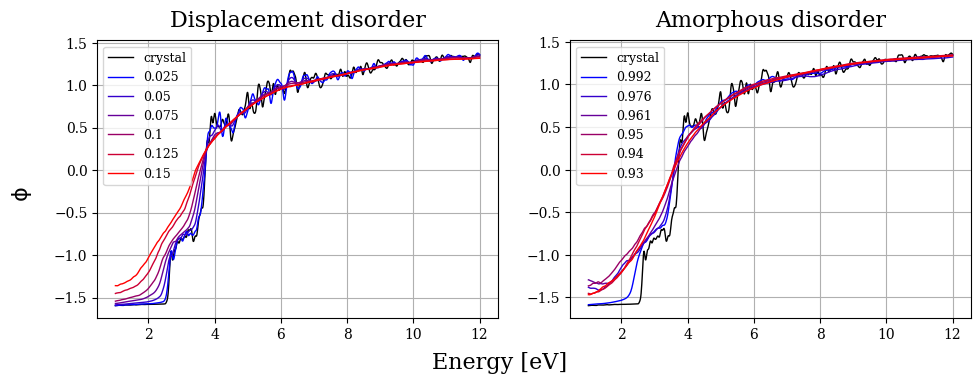

In [27]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# --- сколько графиков будет (по числу init_folders[1:]) ---
folders_to_plot = init_folders[1:]
nplots = len(folders_to_plot)

fig, axes = plt.subplots(1, nplots, figsize=(5*nplots, 4))

fig.subplots_adjust(wspace=0.9, hspace=1)

# если nplots == 1, axes не массив — поправим
if nplots == 1:
    axes = [axes]

for i, init_folder in enumerate(folders_to_plot):

    ax = axes[i]                 # <-- ВОТ ключевое: рисуем в ax, а не в plt
    # ax.set_ylim(0, 5)
    ax.grid(True)

    files_path = Path(init_folder) / "data"
    filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
    filenames_arr = [f for f in filenames_arr if 'lr_response' in f]

    colors = blue_red_gradient(6)

    # reference crystal
    df_ref = pd.read_csv(lr_response_111_path, comment='#', delim_whitespace=True, header=None)
    df_ref.columns = lr_response_columns
    ax.plot(df_ref['Energy_eV'][100:], np.angle(  np.array(df_ref['Im_eps_z'][100:]) + 1j*(1-np.array(df_ref['Re_eps_z'][100:]))  ),
            color='black', label='crystal', linewidth=1)

    # остальные кривые
    for j, f in enumerate(filenames_arr[:6]):
        df = pd.read_csv(files_path / f, comment='#', delim_whitespace=True, header=None)
        df.columns = lr_response_columns

        if 'amorphous' in f:
            labelname = extract_amorphous_value(f)
        else:
            labelname = extract_s_num(f[:20])

        ax.plot(df['Energy_eV'][100:],  np.angle(  np.array(df['Im_eps_z'][100:]) + 1j*(1-np.array(df['Re_eps_z'][100:]))  ),
                color=colors[j], label=labelname, linewidth=1)

    if i==0:
        ax.set_title('Displacement disorder', fontsize=16, y=1.02)

    if i==1:
        ax.set_title('Amorphous disorder', fontsize=16, y=1.02)

    # легенду можно на каждом, или только на последнем/первом
    ax.legend(fontsize=9, loc='upper left')

# общие подписи (как в твоём примере)
fig.supxlabel("Energy [eV]", y=0.05, fontsize=16)
fig.supylabel(r"$\mathrm{\phi}$", x=0.01, fontsize=16)

plt.tight_layout()

plt.savefig("ims/png/phi.png", dpi=200, bbox_inches="tight")
plt.savefig("ims/pdf/phi.pdf", bbox_inches="tight")

plt.show()
plt.close(fig)

In [198]:
# from pathlib import Path
# import matplotlib.pyplot as plt
# import pandas as pd

# # --- сколько графиков будет (по числу init_folders[1:]) ---
# folders_to_plot = init_folders[1:]
# nplots = len(folders_to_plot)

# fig, axes = plt.subplots(1, nplots, figsize=(5*nplots, 4))

# fig.subplots_adjust(wspace=0.9, hspace=1)

# # если nplots == 1, axes не массив — поправим
# if nplots == 1:
#     axes = [axes]

# for i, init_folder in enumerate(folders_to_plot):

#     ax = axes[i]                 # <-- ВОТ ключевое: рисуем в ax, а не в plt
#     # ax.set_ylim(0, 5)
#     ax.grid(True)

#     files_path = Path(init_folder) / "data"
#     filenames_arr = sorted([p.name for p in files_path.iterdir() if p.is_file()])
#     filenames_arr = [f for f in filenames_arr if 'lr_response' in f]

#     colors = blue_red_gradient(6)

#     # reference crystal
#     df_ref = pd.read_csv(lr_response_111_path, comment='#', delim_whitespace=True, header=None)
#     df_ref.columns = lr_response_columns
#     phase_arr=np.angle(  np.array(df_ref['Re_eps_z'][60:]) + 1j*np.array(df_ref['Im_eps_z'][60:])  )
#     ax.plot(df_ref['Energy_eV'][60:], phase_arr,
#             color='black', label='crystal')

#     # остальные кривые
#     for j, f in enumerate(filenames_arr[:6]):
#         df = pd.read_csv(files_path / f, comment='#', delim_whitespace=True, header=None)
#         df.columns = lr_response_columns

#         if 'amorphous' in f:
#             labelname = extract_amorphous_value(f)
#         else:
#             labelname = extract_s_num(f[:20])

#         phase_arr=np.angle(  np.array(df['Re_eps_z'][60:]) + 1j*np.array(df['Im_eps_z'][60:])  )
#         ax.plot(df['Energy_eV'][60:],  phase_arr,
#                 color=colors[j], label=labelname)

#     if i==0:
#         ax.set_title('Displacement disorder', fontsize=16, y=1.02)

#     if i==1:
#         ax.set_title('Amorphous disorder', fontsize=16, y=1.02)

#     # легенду можно на каждом, или только на последнем/первом
#     ax.legend(fontsize=9)

# # общие подписи (как в твоём примере)
# fig.supxlabel("Energy [eV]", y=0.05, fontsize=16)
# fig.supylabel(r"$\mathrm{\phi}$", x=0.01, fontsize=16)

# plt.tight_layout()
# plt.show()
# plt.close(fig)

In [94]:
colors = blue_red_gradient(len(sorted_folders))

plt.figure()
plt.grid()

for j, folder in enumerate(sorted_folders):  
    
    data_lr_response = pd.read_csv(
        folder + '/lr_response.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_lr_response.columns = [
        'Energy_eV',
        'Re_sigma_x', 'Re_sigma_y','Re_sigma_z',
        'Im_sigma_x', 'Im_sigma_y','Im_sigma_z',
        'Re_eps_x',   'Re_eps_y',  'Re_eps_z',
        'Im_eps_x',   'Im_eps_y',  'Im_eps_z'
    ]
    

    plt.plot(data_lr_response['Energy_eV'][50:], data_lr_response['Im_eps_z'][50:], label=folder, color=colors[j])

    # plt.plot(data_lr_response['Energy_eV'][50:], data_lr_response['Re_eps_z'][50:])



    plt.tight_layout()

plt.ylabel(r"Im[$\mathrm{\epsilon}$]") 
plt.xlabel("Energy [eV]")
plt.legend()
plt.savefig("lr_data/ims/png/" + 'epsilon_Im.png', dpi=200)
plt.savefig("lr_data/ims/pdf/" + 'epsilon_Im.pdf', bbox_inches="tight")
plt.close()

In [95]:
colors = blue_red_gradient(len(sorted_folders))

plt.figure()
plt.grid()

for j, folder in enumerate(sorted_folders):  
    
    data_lr_response = pd.read_csv(
        folder + '/lr_response.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_lr_response.columns = [
        'Energy_eV',
        'Re_sigma_x', 'Re_sigma_y','Re_sigma_z',
        'Im_sigma_x', 'Im_sigma_y','Im_sigma_z',
        'Re_eps_x',   'Re_eps_y',  'Re_eps_z',
        'Im_eps_x',   'Im_eps_y',  'Im_eps_z'
    ]
    

    plt.plot(data_lr_response['Energy_eV'][50:], data_lr_response['Re_eps_z'][50:], label=folder, color=colors[j])

    # plt.plot(data_lr_response['Energy_eV'][50:], data_lr_response['Re_eps_z'][50:])



    plt.tight_layout()


plt.ylabel(r"Re[$\mathrm{\epsilon}$]")
plt.xlabel("Energy [eV]")
plt.legend()
plt.savefig("lr_data/ims/png/" + 'epsilon_Re.png', dpi=200)
plt.savefig("lr_data/ims/pdf/" + 'epsilon_Re.pdf', bbox_inches="tight")
plt.close()

In [96]:
plt.figure()
plt.grid()

colors = blue_red_gradient(len(sorted_folders))

for j, folder in enumerate(sorted_folders):  

    data_lr_rt = pd.read_csv(
        folder + '/lr_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    # Назначим читаемые имена колонкам
    data_lr_rt.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    # plt.figure()
    plt.plot(data_lr_rt['time_fs'][:], data_lr_rt['Jm_z'][:], color=colors[j], label=folder)

    
plt.xlabel("Time [fs]")
plt.ylim(-0.01, 0.01)
plt.legend()
plt.savefig("lr_data/ims/png/" + 'lr_rt.png', dpi=200)
plt.savefig("lr_data/ims/pdf/" + 'lr_rt.pdf', bbox_inches="tight")
plt.close()

In [93]:
for j in range(len(sorted_folders)):

    folder = sorted_folders[j]
    source = Path(folder + '/lr_response.data')
    destination = Path("lr_data/data/" + str(j+1) + '_' + folder + "_lr_response.data")
    shutil.copy(source, destination)

    folder = sorted_folders[j]
    source = Path(folder + '/lr_rt.data')
    destination = Path("lr_data/data/" + str(j+1) + '_' + folder + "_lr_rt.data")
    shutil.copy(source, destination)

In [55]:
# def effecive_mass_model(alpha, a, b, c):
#     return 1/(a**2 * alpha**4 + 0*alpha**4 + c)

In [56]:
# delta_start_drude_fit = 300

# def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     t = data_both['time_fs']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     step_dt = 0.002
    


#     t_probe, t_pump = get_pulse_durations(folder)

#     m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
#     m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
#     m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
#     m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    
    
#     dt = np.diff(t, prepend=t[0])
    
    
#     alpha_E_t = np.cumsum(-2.64*El_f_probe_x[m0_cut_3:]*dt[m0_cut_3:])
#     fit_alpha_E_t = alpha_E_t[m0_cut_2-m0_cut_3:]
    
#     alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
#     # --- Задаём поле в дискретных точках ---
#     t_array = np.array(t[m0_cut_2:])         # сетка времени
#     E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
#     # --- Решение через явный шаг Эйлера ---
    
#     j_euler = np.zeros_like(t_array)
#     j_euler[0] = j0
    
#     for k in range(len(t_array)-1):
#         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
#     return j_euler[::1]

In [97]:
# new_taus = []
# new_j_finals = []
# arr_abc = []

# alphas_start = []
# alphas_final = []

    
# folder = sorted_folders[0]

# j=0
# num_folder=0
# for folder in sorted_folders:

#     j=j+1
#     num_folder=num_folder+1
    
#     t_probe, t_pump = get_pulse_durations(folder)
    
#     m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
#     m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
#     m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
#     m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse
    
#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']


#     dt = np.diff(t, prepend=t[0])
    
#     arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
#     a_start = arr[m0_cut_2-m0_cut_3]
#     a_fin = arr[-1]

#     alphas_start.append(a_start)
#     alphas_final.append(a_fin)
    
    
#     # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)
    
    
#     fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)
    
    
    
#     delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x
    
#     # t_array_cut = np.array(t[m0_cut_2:])[::50]
#     # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
#     # # (dummy_t, j0, fit_alpha, j_final)
#     # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
#     # # print(len(t_array_cut), len(j_exp))
#     # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
#     # j0, fit_alpha = popt
#     # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)
    
#     plt.figure(figsize=(7,5))
#     # plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
#     plt.title("Generalized Drude model fit", fontsize=15, y=1.03)
#     plt.plot(t, delta_Jm_x, color='b')
#     # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
#     plt.xlabel("Time [fs]", fontsize=12)
#     plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]", fontsize=12)

#     plt.xticks(fontsize=12)
#     plt.yticks(fontsize=12)

#     plt.legend(fontsize=12)
    
    
#     t_array_cut = np.array(t[m0_cut_2:])[::1]
#     j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
#     # (dummy_t, j0, fit_alpha, j_final)
#     p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
#     # print(len(t_array_cut), len(j_exp))
#     popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
#     [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
#     ))
#     j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
#     j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)
    
#     new_taus.append(fit_tau_val)
#     new_j_finals.append(fit_j_fin_val)
    
#     plt.plot(t_array_cut, j_fit, '-', label=rf'Gen. Drude $m^*: \tau = {fit_tau_val:.2f}\ \mathrm{{fs}}$', color='r')
#     plt.legend()
#     plt.grid()
#     arr_abc.append((a, b, c))
#     print(a, b, c)

#     plt.tight_layout()

#     plt.savefig("all_data/drude/ims/png/" + str(j)+ '_drude_fit_' + folder + ".png", dpi=200)
#     plt.savefig("all_data/drude/ims/pdf/" + str(j)+ '_drude_fit_' + folder + ".pdf", bbox_inches="tight")

#     print("For " + folder + " drude fit plots are completed")




#     j_fit_extended = np.concatenate(([None]*m0_cut_2, j_fit))
    
#     drude_current_arr=np.array([t, delta_Jm_x, j_fit_extended])

#     columns = ["time",  "delta_Jm_x", "delta_Jm_x_drude_fit"]
#     df = pd.DataFrame(drude_current_arr.T, columns=columns)
    
    
#     df.to_csv("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", index=False)
    
#     with open("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", "w") as f:
#         f.write(r"# Units: Time [fs], Current Jm [1/fs*Angstrom^2]" + "\n")
#         df.to_csv(f, index=False)
    
#     print("For " + folder + " drude fit current data saving in csv format is completed")

    


# print(" ")

In [98]:
# from matplotlib.colors import to_hex

# def blue_red_gradient(n):
#     """
#     Возвращает список из n цветов (hex),
#     создающих линейный градиент от синего к красному.
#     """
#     colors = []
    
#     for i in range(n):
#         t = i / (n - 1)  # параметр от 0 до 1
        
#         r = t            # красный растёт
#         g = 0            # зелёный фиксирован
#         b = 1 - t        # синий убывает
        
#         colors.append(to_hex((r, g, b)))
    
#     return colors

In [98]:
# colors=['coral', 'b', 'r', 'm', 'g', 'orange', 'gold', 'purple', 'slateblue', 'olive', 'navy', 'darkred']

# if len(sorted_folders)<12:


#     plt.figure(figsize=(8,5))
#     plt.title("Drude mass dependence on wave vector", fontsize=15)
    
    
#     plt.xticks(fontsize=12)
#     plt.yticks(fontsize=12)
    
#     plt.legend(fontsize=12)
    
#     plot_part=1
#     num_folder=0
#     for (a0, b0, c0) in arr_abc:
#         num_folder+=1
#         if num_folder!=0:
#             plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), 
#             [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
#             plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2, color=colors[num_folder-1])

#     j=j+1
#     plt.grid()
#     plt.legend()
#     plt.xlabel(r'$\Delta \, k \, [\pi/a]$', fontsize=12)
#     # plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
#     # plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
#     plt.ylabel(r'$m^{*}\, [m_e]$', fontsize=12, rotation=0,  labelpad=30)
#     plt.tight_layout()
    
#     plt.savefig("all_data/drude/ims/png/" + 'drude_m_dependence.png', dpi=200)
#     plt.savefig("all_data/drude/ims/pdf/" + 'drude_m_dependence.pdf', bbox_inches="tight")

#     print("Effective mass plots are completed")
#     print(" ")


    
#     # plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

In [99]:
# num_folder=0
# for (a0, b0, c0) in arr_abc:
#     num_folder+=1

#     delta_k_vals = np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)
    
#     effective_mass_vals = [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
#     plot_part*alphas_final[num_folder-1], 500)]
    
#     effective_mass_data=np.array([delta_k_vals, effective_mass_vals])

#     columns = ["delta_k",  "effective_mass"]
#     df = pd.DataFrame(effective_mass_data.T, columns=columns)
    
    
#     df.to_csv("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", index=False)
    
#     with open("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", "w") as f:
#         f.write(r"# Units: Wave vector during the probe pulse $\Delta k$ [$\pi/a$], Effective mass $m^{*}$ [$m_e$]" + "\n")
#         df.to_csv(f, index=False)
    
#     print("For " + sorted_folders[num_folder-1] + " effective mass data saving in csv format is completed")


# print(" ")

In [57]:
# plt.figure(figsize=(6, 4))

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.legend(fontsize=12)

# plt.title("Drude relaxation and FID comparison", fontsize=14)
# folder_nums = np.linspace(1, len(new_taus), len(new_taus))
# plt.plot(folder_nums, new_taus, color='b', label=r'$\tau_{drude}^x$')
# plt.plot(folder_nums, tau_fid_z_arr, color='r', label=r'$\tau_{fid}^z$')

# plt.plot(folder_nums, np.array(mandels_coherence_arr), color='g', label=r'$\tau_{coherence}^z$')
# plt.scatter(folder_nums, np.array(mandels_coherence_arr), color='black')


# plt.plot(folder_nums, np.array(auto_corr_mandels_coherence), color='m', label=r'$\tau_{autocorr_coherence}^z$')
# plt.scatter(folder_nums, np.array(auto_corr_mandels_coherence), color='black')

# plt.scatter(folder_nums, new_taus, color='black')
# plt.scatter(folder_nums, tau_fid_z_arr, color='black')
# plt.ylabel("Time [fs]", fontsize=12)
# plt.xlabel("Folder #", fontsize=12)
# plt.xticks(folder_nums)
# plt.legend(fontsize=12)
# plt.grid()
# plt.tight_layout()

# plt.savefig("all_data/fid/" + 'tau_comparison.png', dpi=200)
# plt.savefig("all_data/fid/" + 'tau_comparison.pdf', bbox_inches="tight")

## draft

In [18]:
# folder = sorted_folders[0]

# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# pulse_data_both = pd.read_csv(
#     folder + '/both_pulses_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# pulse_data_pump = pd.read_csv(
#     folder + '/pump_pulse_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# pulse_data_probe = pd.read_csv(
#     folder + '/probe_pulse_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# pulse_data_both.columns = [
#     'Energy_eV',

#     'Re_Jm_x', 'Re_Jm_y', 'Re_Jm_z',
#     'Im_Jm_x', 'Im_Jm_y', 'Im_Jm_z',
#     'Abs2_Jm_x', 'Abs2_Jm_y', 'Abs2_Jm_z',

#     'Re_El_f_Ext_x', 'Re_El_f_Ext_y', 'Re_El_f_Ext_z',
#     'Im_El_f_Ext_x', 'Im_El_f_Ext_y', 'Im_El_f_Ext_z',
#     'Abs2_El_f_Ext_x', 'Abs2_El_f_Ext_y', 'Abs2_El_f_Ext_z',

#     'Re_El_f_Tot_x', 'Re_El_f_Tot_y', 'Re_El_f_Tot_z',
#     'Im_El_f_Tot_x', 'Im_El_f_Tot_y', 'Im_El_f_Tot_z',
#     'Abs2_El_f_Tot_x', 'Abs2_El_f_Tot_y', 'Abs2_El_f_Tot_z'
# ]

# pulse_data_pump.columns  = pulse_data_both.columns

# pulse_data_probe.columns = pulse_data_both.columns


# energies = pulse_data_both['Energy_eV']


# Abs2_Jm_both_z  =  pulse_data_both['Abs2_Jm_z']
# Abs2_Jm_pump_z  =  pulse_data_pump['Abs2_Jm_z']
# Abs2_Jm_probe_z =  pulse_data_probe['Abs2_Jm_z']

# Abs2_Jm_both_x  =  pulse_data_both['Abs2_Jm_x']
# Abs2_Jm_pump_x  =  pulse_data_pump['Abs2_Jm_x']
# Abs2_Jm_probe_x =  pulse_data_probe['Abs2_Jm_x']

# Abs2_Jm_both_y  =  pulse_data_both['Abs2_Jm_y']
# Abs2_Jm_pump_y  =  pulse_data_pump['Abs2_Jm_y']
# Abs2_Jm_probe_y =  pulse_data_probe['Abs2_Jm_y']

In [349]:
# plt.plot(energies, Abs2_Jm_both_x, color='b')
# plt.plot(energies, Abs2_Jm_pump_x, color='r')
# plt.plot(energies, Abs2_Jm_probe_x, color='g')
# plt.xlim(0, 6)
# plt.ylim(0, 0.0001)

## draft

In [350]:
# def effecive_mass_model(alpha, a, b, c):
#     return 1/(a**2 * alpha**4 + 0*alpha + c)

In [351]:
# def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     t = data_both['time_fs']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     step_dt = 0.002
    
#     m0_cut_2 = 6250
    
#     dt = np.diff(t, prepend=t[0])
    
    
#     alpha_E_t = np.cumsum(-2.64*El_f_probe_x[5250:]*dt[5250:])
#     fit_alpha_E_t = alpha_E_t[1000:]
    
#     alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
#     # --- Задаём поле в дискретных точках ---
#     t_array = np.array(t[m0_cut_2:])         # сетка времени
#     E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
#     # --- Решение через явный шаг Эйлера ---
    
#     j_euler = np.zeros_like(t_array)
#     j_euler[0] = j0
    
#     for k in range(len(t_array)-1):
#         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
#     return j_euler[::1]

In [58]:
# get_n_excited_electrons(sorted_folders[0])[0]

In [59]:
# sorted_folders

In [352]:
# plt.figure(figsize=(8,5))
# plt.title("Drude factor dependence on disorder")

# plot_part=1
# num_folder=0
# for (a0, b0, c0) in arr_abc:
#     num_folder+=1
#     if num_folder!=0:
#         plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2)

# plt.grid()
# plt.legend()
# plt.xlabel(r'$\Delta \, k \, [\pi/a]$')
# # plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
# # plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
# plt.ylabel(r'$m^{*}\, [m_e]$', rotation=0,  labelpad=30)
# plt.show()

# # plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

## draft FID

In [353]:
# new_taus = []
# new_j_finals = []
# arr_abc = []

    
# folder = sorted_folders[0]

# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# data_both = pd.read_csv(
#     folder + '/both_pulses_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# data_probe = pd.read_csv(
#     folder + '/probe_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# data_pump = pd.read_csv(
#     folder + '/pump_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# # Назначим читаемые имена колонкам
# data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']


# t = data_both['time_fs']


# Jm_both_z  =  data_both['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']


# El_f_pump_z = data_both['E_ext_z']
# El_f_probe_x = data_both['E_ext_x']


# # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)


# fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)



# delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x

# # t_array_cut = np.array(t[m0_cut_2:])[::50]
# # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
# # # (dummy_t, j0, fit_alpha, j_final)
# # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
# # # print(len(t_array_cut), len(j_exp))
# # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
# # j0, fit_alpha = popt
# # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)

# plt.figure(figsize=(8,5))
# plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
# plt.plot(t, delta_Jm_x, color='b')
# # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
# plt.xlabel("Time [fs]")
# plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]")


# t_array_cut = np.array(t[m0_cut_2:])[::1]
# j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
# # (dummy_t, j0, fit_alpha, j_final)
# p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
# # print(len(t_array_cut), len(j_exp))
# popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
# [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
# ))
# j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
# j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)

# new_taus.append(fit_tau_val)
# new_j_finals.append(fit_j_fin_val)

# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.legend()
# plt.grid()
# arr_abc.append((a, b, c))
# print(a, b, c)

In [354]:
# import numpy as np
# import pandas as pd
# from scipy.interpolate import CubicSpline

# def build_nonFID_component_with_zero_plateau(
#     t,                 # pd.Series или np.ndarray, полная сетка времени
#     t_array_cut,       # np.ndarray, время для друде-фита (начиная ~12.5 fs)
#     j_fit,             # np.ndarray, значения друде-фита
#     t_zero_end=9.0,    # fs: до этого времени nonFID принудительно 0
#     halfmax=0.5,       # t1 = первая точка, где j_fit >= halfmax*max
# ):
#     t_full = np.asarray(t, dtype=float)
#     t_cut = np.asarray(t_array_cut, dtype=float)
#     j_cut = np.asarray(j_fit, dtype=float)

#     if t_cut.shape != j_cut.shape:
#         raise ValueError("t_array_cut и j_fit должны быть одинаковой длины.")

#     # сортировка на всякий случай
#     order = np.argsort(t_cut)
#     t_cut = t_cut[order]
#     j_cut = j_cut[order]

#     # --- t1 по halfmax ---
#     jmax = np.nanmax(j_cut)
#     if not np.isfinite(jmax) or jmax == 0:
#         raise ValueError("j_fit выглядит нулевым/некорректным (max=0 или NaN).")

#     thresh = halfmax * jmax
#     idxs = np.flatnonzero(j_cut >= thresh)
#     if len(idxs) == 0:
#         raise ValueError("Не нашёл точку, где j_fit >= halfmax * max(j_fit).")
#     i1 = idxs[0]
#     if i1 >= len(j_cut) - 1:
#         raise ValueError("Точка halfmax слишком близко к концу — нельзя оценить производную.")

#     t1 = t_cut[i1]
#     y1 = j_cut[i1]
#     dydt1 = (j_cut[i1 + 1] - j_cut[i1]) / (t_cut[i1 + 1] - t_cut[i1])

#     # проверка, что зона нулевого плато действительно раньше стыка
#     if t1 <= t_zero_end:
#         raise ValueError(
#             f"Получилось t1={t1:.3g} fs <= t_zero_end={t_zero_end:.3g} fs. "
#             "Нужно уменьшить t_zero_end или иначе выбирать t1."
#         )

#     # --- полиномное включение, но начиная с t_zero_end ---
#     # Используем τ = t - t0z, где t0z = t_zero_end
#     # y(τ) = a τ^3 + b τ^2
#     # y(0)=0 и y'(0)=0 автоматически
#     # Подбираем a,b так, чтобы в τ1 = (t1 - t0z): y=y1 и dy/dt = dydt1
#     tau1 = t1 - t_zero_end
#     a = (dydt1 * tau1 - 2.0 * y1) / (tau1**3)
#     b = (3.0 * y1 - dydt1 * tau1) / (tau1**2)

#     nonFID = np.zeros_like(t_full)

#     # t <= t_zero_end : строго 0
#     # t_zero_end < t < t1 : полином по τ
#     s_poly = (t_full > t_zero_end) & (t_full < t1)
#     tau = t_full[s_poly] - t_zero_end
#     nonFID[s_poly] = a * tau**3 + b * tau**2

#     # t >= t1 : сплайн по Drude fit (с экстраполяцией)
#     spline = CubicSpline(t_cut, j_cut, extrapolate=True)
#     s_spline = t_full >= t1
#     nonFID[s_spline] = spline(t_full[s_spline])

#     info = {
#         "t_zero_end": t_zero_end,
#         "t1": t1,
#         "y1": y1,
#         "dydt1": dydt1,
#         "a": a,
#         "b": b,
#         "halfmax": halfmax,
#     }
#     return nonFID, info


# def subtract_nonFID_and_get_FID_with_zero_plateau(
#     t, delta_Jm_x, t_array_cut, j_fit, t_zero_end=9.0, halfmax=0.5
# ):
#     nonFID, info = build_nonFID_component_with_zero_plateau(
#         t=t,
#         t_array_cut=t_array_cut,
#         j_fit=j_fit,
#         t_zero_end=t_zero_end,
#         halfmax=halfmax,
#     )

#     if isinstance(delta_Jm_x, pd.Series):
#         fid_vals = delta_Jm_x.values - nonFID
#         fid = pd.Series(fid_vals, index=delta_Jm_x.index, name="FID_component")
#         nonFID_out = pd.Series(nonFID, index=delta_Jm_x.index, name="nonFID_component")
#     else:
#         fid = np.asarray(delta_Jm_x, dtype=float) - nonFID
#         nonFID_out = nonFID

#     return fid, nonFID_out, info


In [355]:
# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=8.5,   # твоя физическая “ноль-зона”
#     halfmax=0.85
# )

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID")
# # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# # plt.axvline(info["t1"], linestyle="--", label="t1")
# # plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [356]:
# import scipy

# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=8.5,   # твоя физическая “ноль-зона”
#     halfmax=0.85
# )

# print("Mandel's coherence time: ",coherence_time(fid, 0.002))
# print("Drude relaxation time: ", fit_tau_val)

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID", color='b')
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# # plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# # plt.axvline(info["t1"], linestyle="--", label="t1")
# # plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [357]:
# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=10.5,   # твоя физическая “ноль-зона”
#     halfmax=0.5
# )

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID")
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# plt.axvline(info["t1"], linestyle="--", label="t1")
# plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [358]:
# def coherence_time(Y, dt) -> float:
#     r"""
#     Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

#     The function implements Mandel's coherence time. It calculates the autocorrelation
#     function of the given signal, then it calculates the complex envelope of the
#     autocorrelation function, and integrates the square of the normalized envelope from
#     t=0 to the maximal time. The coherence time is twice the value of the integral.

#     Args:
#       Y: 1D array that represents the time-dependent signal on a regular grid.
#       dt: Time step of the grid.

#     Returns:
#       the coherence time as a floating-point number.
#     """
#     ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
#     N = len(Y)
#     # X = dt * np.arange(-(N - 1), N) # DEBUGGING
#     ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
#     ACF_envelope /= np.max(ACF_envelope)
#     i1 = N - 1 # np.flatnonzero(X >= 0)[0]
#     # print("X[i1] =", X[i1]) # DEBUGGING
#     return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

## draft v2

In [359]:

# folder = sorted_folders[0]
# ax = 'z'
# j = 0


# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# data_both = pd.read_csv(
#     folder + '/both_pulses_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# data_pump = pd.read_csv(
#     folder + '/pump_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# data_probe = pd.read_csv(
#     folder + '/probe_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# # Назначим читаемые имена колонкам
# data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']


# t = data_both['time_fs']


# Jm_both_z  =  data_both['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']


# El_f_pump_z = data_both['E_ext_z']
# El_f_probe_x = data_both['E_ext_x']


# # 1:Time[fs] 2:Ac_ext_x[fs*V/Angstrom] 3:Ac_ext_y[fs*V/Angstrom] 4:Ac_ext_z[fs*V/Angstrom]
# #5:E_ext_x[V/Angstrom] 6:E_ext_y[V/Angstrom] 7:E_ext_z[V/Angstrom] 8:Ac_tot_x[fs*V/Angstrom]
# # 9:Ac_tot_y[fs*V/Angstrom] 10:Ac_tot_z[fs*V/Angstrom] 11:E_tot_x[V/Angstrom]
# # 12:E_tot_y[V/Angstrom] 13:E_tot_z[V/Angstrom]  14:Jm_x[1/fs*Angstrom^2] 15:Jm_y[1/fs*Angstrom^2] 16:Jm_z[1/fs*Angstrom^2]


# # Построим графики
# plt.figure(figsize=(10, 12.5))

# # Общий заголовок для всей фигуры
# plt.suptitle(' '.join(re.split('[/_]', folder)), fontsize=14, y=0.99)

# # Первый график: внешнее поле по z
# plt.subplot(5, 2, 1)
# plt.plot(t, El_f_pump_z, label='E_ext_z', color='#2CD311')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [V/Å]')
# plt.title('Pump external electric field z')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()

# # Второй график: внешнее поле по x
# plt.subplot(5, 2, 2)
# plt.plot(t, El_f_probe_x, label='E_ext_z', color='c')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [V/Å]')
# plt.title('Probe external electric field x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()

# # Четвертый график: суммарный ток по z
# plt.subplot(5, 2, 4)
# plt.plot(t, Jm_both_z, color='magenta')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along z')
# plt.grid(True)

# plt.tight_layout()



# product_both_z = El_f_pump_z * Jm_both_z * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_both_z = np.cumsum(product_both_z * dt)

# product_both_x = El_f_probe_x * Jm_both_x * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_both_x = np.cumsum(product_both_x * dt)

# product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_delta_x = np.cumsum(product_delta_x * dt)



# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 3)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_both_z, label='ΔE = E_total - E_initial', color='r')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Energy transfer per unit cell along z')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()



# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 5)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_both_x, label='ΔE = E_total - E_initial', color='blue')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Energy transfer per unit cell along x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()


# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 6)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_delta_x, label='ΔE = E_total - E_initial', color='black')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Δ energy transfer per unit cell along x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()



# # Суммарный ток по x
# plt.subplot(5, 2, 7)
# plt.plot(t, Jm_both_x, color='#DC143C')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along x')
# plt.grid(True)
# plt.tight_layout()




# delta_Jm_x = Jm_both_x - Jm_pump_x - Jm_probe_x


# t_array_cut = np.array(t[m0_cut_1:])[::50]
# j_exp = np.array(delta_Jm_x[m0_cut_1:])[::50]
# # (dummy_t, j0, j_final, tau)
# p0 = [0.03, 0.01, 6.65]   # начальные приближения (n, tau)
# popt, pcov = curve_fit(drude_current_v1, t_array_cut, j_exp, p0=p0)
# j0, j_final, tau= popt
# j_fit = drude_current_v1(0, j0, j_final, tau)

# ratio = j_final/max(delta_Jm_x)

# # Разностный ток по x
# plt.subplot(5, 2, 8)
# plt.plot(t, (Jm_both_x - Jm_pump_x - Jm_probe_x), color='#00FF7F')
# plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau:.2f}\ \mathrm{{fs}} \quad j_{{\rm final}} : j_{{\rm max}} = {ratio:.2f}$", color='r')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Δ matter current density along x')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()




# # Суммарный ток по y
# plt.subplot(5, 2, 9)
# plt.plot(t, Jm_both_y, color='#00BFFF')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along y')
# plt.grid(True)
# plt.tight_layout()


# # Разностный ток по y
# plt.subplot(5, 2, 10)
# plt.plot(t, (Jm_both_y - Jm_pump_y - Jm_probe_y), color='#FF007F')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Δ matter current density along y')
# plt.grid(True)
# plt.tight_layout()





# # lr_data = pd.read_csv(
# #     folder + '/lr_response.data',
# #     comment='#',
# #     delim_whitespace=True,
# #     header=None
# # )

# # lr_data.columns = [
# #     'Energy',        # 1
# #     'Re_sigma_x',    # 2
# #     'Re_sigma_y',    # 3
# #     'Re_sigma_z',    # 4
# #     'Im_sigma_x',    # 5
# #     'Im_sigma_y',    # 6
# #     'Im_sigma_z',    # 7
# #     'Re_eps_x',      # 8
# #     'Re_eps_y',      # 9
# #     'Re_eps_z',      # 10
# #     'Im_eps_x',      # 11
# #     'Im_eps_y',      # 12
# #     'Im_eps_z',      # 13
# # ]


# # # Построение графика изменения энергии во времени
# # plt.subplot(5, 2, 9)
# # plt.plot(lr_data['Energy'][100:], lr_data['Im_eps_z'][100:], label='Im(ε)', color='#00BFFF')
# # plt.xlabel('E [eV]')
# # plt.ylabel('Im(ε)')
# # plt.title('Absorption')
# # plt.grid(True)
# # #plt.legend()
# # plt.tight_layout()

# # # Построение графика изменения энергии во времени
# # plt.subplot(5, 2, 10)
# # plt.plot(lr_data['Energy'][100:], lr_data['Re_eps_z'][100:], label='Re(ε)', color='#FF007F')
# # plt.xlabel('E [eV]')
# # plt.ylabel('Re(ε)')
# # plt.title('Dispersion')
# # plt.grid(True)
# # #plt.legend()
# # plt.tight_layout()
# # # plt.show()

# # plt.savefig("ims/all/" + folder + ".pdf")
# # plt.savefig("ims/all/" + str(j)+ '_' + folder + ".png", dpi=200)

# dt = np.diff(t, prepend=t[0])

# arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
# a_start = arr[m0_cut_2-m0_cut_3]
# a_fin = arr[-1]




# # In[ ]:


In [360]:

# for folder in sorted_folders:

#     # folder = sorted_folders[0]
#     ax = 'z'
#     j = 0


#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     plt.figure(figsize=(6, 4))
#     print(folder)
#     plt.plot(t, El_f_probe_x/20, color='g')
#     plt.plot(t, Jm_pump_x, color='b')
#     plt.plot(t, Jm_both_x, color='r')
#     plt.plot(t, Jm_probe_x, color='#00BFFF')
#     plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
#     plt.xlabel('Time [fs]')
#     plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
#     plt.title('Full matter current density along x,  probe')
#     plt.grid(True)
#     plt.tight_layout()

In [361]:

# for folder in sorted_folders:

#     # folder = sorted_folders[0]
#     ax = 'z'
#     j = 0


#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
#     Jm_pump_z  =  data_pump['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     plt.figure(figsize=(6, 4))
#     print(folder)
#     # plt.plot(t, El_f_probe_x/20, color='g')
#     plt.plot(t, Jm_both_z/5, color='b')
#     plt.plot(t, Jm_pump_z/5, color='black')
#     plt.plot(t, Jm_pump_z-Jm_both_z, color='r')
#     # plt.plot(t, Jm_both_y, color='r')
#     # plt.plot(t, Jm_probe_y, color='#00BFFF')
#     # plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
#     plt.xlabel('Time [fs]')
#     plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
#     plt.title('Full matter current density along x,  probe')
#     plt.grid(True)
#     plt.tight_layout()

## get data

In [362]:
# Jm_both_z  =  data_both['Jm_z']
# Jm_pump_z  =  data_pump['Jm_z']
# Jm_probe_z =  data_probe['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']

In [363]:
# plt.plot(t, Jm_both_z, color='b', label='both')
# plt.plot(t, Jm_pump_z, color='r', label='pump')
# plt.plot(t, Jm_probe_z, color='green', label='probe')
# # plt.plot(t, (Jm_pump_z-Jm_both_z+Jm_probe_z), color='black', label='delta')
# plt.plot(t, -1*El_f_pump_z*max(-Jm_both_z)/max(El_f_pump_z), linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Matter current density along the z-axis')
# # plt.ylim(-0.015, 0.015)
# plt.legend()
# plt.grid()

In [364]:
# # plt.plot(t, Jm_probe_z, color='green', label='probe')
# # plt.plot(t, (Jm_both_z-Jm_pump_z-Jm_probe_z), color='black', label='delta')
# plt.plot(t, -Jm_pump_z, color='b')
# plt.grid()
# plt.ylim(-0.02, 0.02)

In [365]:
# plt.plot(t, Jm_both_x, color='b', label='both')
# plt.plot(t, Jm_pump_x, color='r', label='pump')
# plt.plot(t, Jm_probe_x, color='green', label='probe')
# plt.plot(t, (Jm_both_x-Jm_pump_x-Jm_probe_x), color='black', label='delta')
# plt.plot(t, -4*El_f_probe_x*max(-Jm_both_x)/max(El_f_probe_x), linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Matter current density along the z-axis')
# plt.legend()
# plt.grid()

In [375]:
# plt.plot(t, -integral_both_x, color='b', label='both')
# plt.plot(t, -integral_pump_x, color='r', label='pump')
# plt.plot(t, -integral_probe_x, color='green', label='probe')
# plt.plot(t, -integral_delta_x, color='black', label='delta')
# plt.plot(t, El_f_probe_x*max(-integral_both_x)/max(El_f_probe_x)/6, linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along x-direction')
# plt.legend()
# plt.grid()

In [376]:
# plt.plot(t, -integral_both_z, color='b', label='both')
# plt.plot(t, -integral_pump_z, color='r', label='pump')
# plt.plot(t, -integral_probe_z, color='green', label='probe')
# plt.plot(t, -integral_both_z+integral_pump_z+integral_probe_z, color='black', label='delta')
# plt.plot(t, El_f_pump_z*max(-integral_both_z)/max(El_f_pump_z)/6, linestyle="--", color='m', label='pump field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along z-direction')
# plt.legend()
# plt.grid()

In [366]:
# each_num=10

# current_energy_array=np.array([ t[::each_num], El_f_pump_z[::each_num], El_f_probe_x[::each_num],
#                   Jm_both_z[::each_num], Jm_pump_z[::each_num], Jm_probe_z[::each_num],
#                   Jm_both_y[::each_num], Jm_pump_y[::each_num], Jm_probe_y[::each_num],
#                   Jm_both_x[::each_num], Jm_pump_x[::each_num], Jm_probe_x[::each_num]
#                 ])
# columns = ["time", "El_f_pump_z", "El_f_probe_x", "Jm_both_z", "Jm_pump_z", "Jm_probe_z", "Jm_both_y", "Jm_pump_y", "Jm_probe_y", 
#            "Jm_both_x", "Jm_pump_x", "Jm_probe_x"]
# df = pd.DataFrame(current_energy_array.T, columns=columns)


# df.to_csv("current_data.csv", index=False)

# with open("current_data.csv", "w") as f:
#     f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2], Electric field El_f[V/Angstrom], Energy En[eV]\n")
#     df.to_csv(f, index=False)


# df_read = pd.read_csv("current_data.csv", comment="#")

# df_read

In [367]:
# df_read = pd.read_csv("current_data.csv", comment="#")

# df_read